In [1]:
import torch
from denoising_diffusion_pytorch import Unet, GaussianDiffusion, Trainer1D, Dataset1D
from pathlib import Path
import numpy as np

/global/homes/k/kp22/.conda/envs/denoising_diffusion_pytorch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.cuda.get_device_name(0)

'NVIDIA A100-PCIE-40GB'

In [3]:
model = Unet(
    dim = 64,
    dim_mults = (1, 2, 4, 8),
    channels=2,
    flash_attn = True
)

diffusion = GaussianDiffusion(
    model,
    image_size = 256,
    timesteps = 1000    # number of steps
)
diffusion.to(device);

Non-A100 GPU detected, using math or mem efficient attention if input tensor is on cuda


In [4]:
ptsrc=2
fpath_cib = f"data/low_pass/{ptsrc}mJy/CIB_map_95GHz_256_st6_minmax_{ptsrc}mJy_zero_lp.npy"
fpath_tsz = f"data/low_pass/{ptsrc}mJy/CIB_map_95GHz_256_st6_minmax_{ptsrc}mJy_zero_lp.npy"

cib_maps = np.load(fpath_cib)  # (N, H, W, 1)
tsz_maps = np.load(fpath_tsz)  # (N, H, W, 1)

# Stack along channel axis: (N, H, W, 2)
joint_maps = np.concatenate([cib_maps, tsz_maps], axis=-1)
joint_maps = joint_maps.transpose(0, 3, 1, 2)  # (N, 2, H, W)

In [5]:
joint_maps.shape

(1041, 2, 256, 256)

In [6]:
fpath = "data/low_pass/2mJy/cut_maps_RES_256_ANG_X_6.0_deg_2mJy_lp_CIB150.npy"

cut_maps = np.load(fpath)
cut_maps = cut_maps.transpose(0, 3, 1, 2)

num_samples = len(cut_maps)
num_train = int(0.8 * num_samples)

# Create a local random number generator
rng = np.random.default_rng(seed=42)

# Shuffle and split the data
indices = rng.permutation(num_samples)
train_indices = indices[:num_train]

# Create the training tensor
training_images = torch.tensor(cut_maps[train_indices], dtype=torch.float32)

In [7]:
def augment_images_unique(training_images):
    augmented_images = []
    for image in training_images:
            transforms = [
                image,
                torch.rot90(image, k=1, dims=(1, 2)),   # 90°
                torch.rot90(image, k=2, dims=(1, 2)),   # 180°
                torch.rot90(image, k=3, dims=(1, 2)),   # 270°
            ]

            for t_img in transforms:
                augmented_images.append(t_img)  # original and rotated versions
                augmented_images.append(torch.flip(t_img, dims=[2]))  # horizontal flip of each rotated version

    return torch.stack(augmented_images)

In [8]:
augmented_images = augment_images_unique(training_images)

In [9]:
np.shape(augmented_images),np.shape(training_images)

(torch.Size([6656, 1, 256, 256]), torch.Size([832, 1, 256, 256]))

In [10]:
total_params = sum(param.numel() for param in model.parameters())
print(f"Total parameters: {total_params/1e6} M")

Total parameters: 35.70829 M


In [11]:
from torchinfo import summary
from torch import nn

In [12]:
def get_named_block_param_counts(model):
    block_summaries = []

    for name, module in model.named_children():
        total_params = sum(p.numel() for p in module.parameters() if p.requires_grad)

        if isinstance(module, nn.ModuleList):
            for i, sub in enumerate(module):
                label = f"{name}[{i}] - {sub.__class__.__name__}"
                count = sum(p.numel() for p in sub.parameters() if p.requires_grad)
                block_summaries.append((label, count))
        else:
            block_summaries.append((name, total_params))

    return block_summaries

# Example usage
summary = get_named_block_param_counts(model)
print(f"{'Block':<40} {'Param #'}")
print("-" * 55)
for name, count in summary:
    print(f"{name:<40} {count:,}")

Block                                    Param #
-------------------------------------------------------
init_conv                                6,336
time_mlp                                 82,432
downs[0] - ModuleList                    264,192
downs[1] - ModuleList                    280,640
downs[2] - ModuleList                    920,704
downs[3] - ModuleList                    3,937,280
ups[0] - ModuleList                      14,558,464
ups[1] - ModuleList                      3,839,360
ups[2] - ModuleList                      1,060,032
ups[3] - ModuleList                      374,912
mid_block1                               4,983,808
mid_attn                                 264,192
mid_block2                               4,983,808
final_res_block                          152,000
final_conv                               130


In [13]:
diffusion.objective

'pred_v'


### UNet stage‑wise parameter breakdown
| Stage           |   Params |   Millions |   Percent |
|:----------------|---------:|-----------:|----------:|
| ups[0]          | 14558464 |     14.558 |    40.770 |
| mid_block2      |  4983808 |      4.984 |    13.960 |
| mid_block1      |  4983808 |      4.984 |    13.960 |
| downs[3]        |  3937280 |      3.937 |    11.030 |
| ups[1]          |  3839360 |      3.839 |    10.750 |
| ups[2]          |  1060032 |      1.060 |     2.970 |
| downs[2]        |   920704 |      0.921 |     2.580 |
| ups[3]          |   374912 |      0.375 |     1.050 |
| downs[1]        |   280640 |      0.281 |     0.790 |
| downs[0]        |   264192 |      0.264 |     0.740 |
| mid_attn        |   264192 |      0.264 |     0.740 |
| final_res_block |   152000 |      0.152 |     0.430 |
| time_mlp        |    82432 |      0.082 |     0.230 |
| init_conv       |     6336 |      0.006 |     0.020 |
| final_conv      |      130 |      0.000 |     0.000 |

Saved 

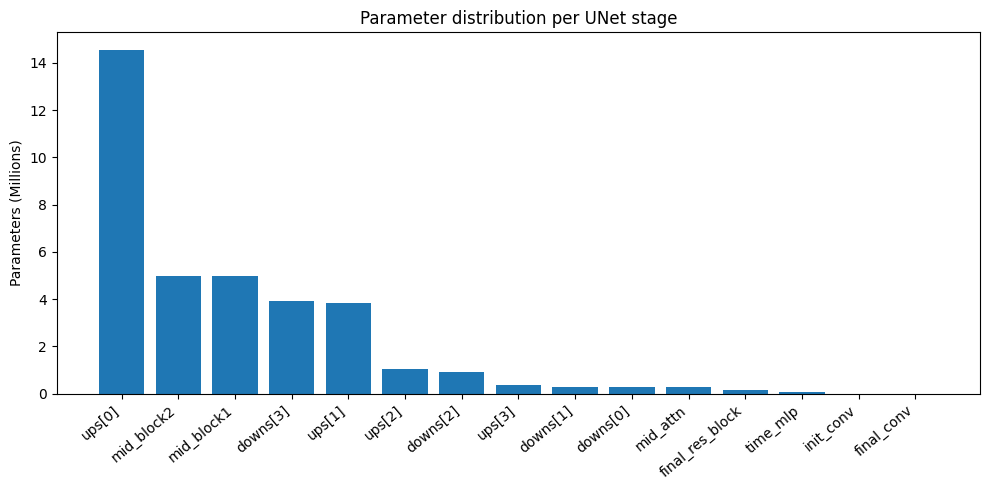

In [17]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- your model ---------------------------------------------------------------
model = Unet(dim=64, dim_mults=(1, 2, 4, 8), channels=2, flash_attn=True)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# --- helper: param counts by top‑level block ----------------------------------
def named_block_param_counts(m: nn.Module):
    rows = []
    for name, module in m.named_children():
        if isinstance(module, nn.ModuleList):
            # keep the individual lists separate (downs[0], ups[1], …)
            for i, sub in enumerate(module):
                label = f"{name}[{i}]"
                rows.append((label, sum(p.numel() for p in sub.parameters()
                                        if p.requires_grad)))
        else:
            rows.append((name, sum(p.numel() for p in module.parameters()
                                   if p.requires_grad)))
    return rows

rows = named_block_param_counts(model)

# --- build DataFrame ----------------------------------------------------------
df = (
    pd.DataFrame(rows, columns=["Stage", "Params"])
      .assign(Millions=lambda d: (d["Params"] / 1e6).round(3),
              Percent=lambda d: (d["Params"] / total_params * 100).round(2))
      .sort_values("Params", ascending=False)
      .reset_index(drop=True)
)

# --- 1) pretty Markdown table -------------------------------------------------
print("\n### UNet stage‑wise parameter breakdown")
print(df.to_markdown(index=False, floatfmt=".3f"))

# --- 2) CSV (for Excel or a poster) ------------------------------------------
df.to_csv("unet_param_summary.csv", index=False)
print("\nSaved `unet_param_summary.csv`")

# --- 3) LaTeX table (paste straight into Overleaf) ----------------------------
latex_path = Path("unet_param_summary.tex")
with latex_path.open("w") as f:
    f.write(df.to_latex(index=False, float_format="%.3f"))
print(f"Saved `{latex_path}`")

# --- 4) Quick bar chart -------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.bar(df["Stage"], df["Millions"])
plt.ylabel("Parameters (Millions)")
plt.title("Parameter distribution per UNet stage")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
from torchviz import make_dot
import graphviz
from torchview import draw_graph

In [ ]:
BATCH_SIZE, IMG_CH, IMG_SIZE = 32, 1, 256
timesteps =1000
dummy_input = (
    torch.randn(BATCH_SIZE, IMG_CH, IMG_SIZE, IMG_SIZE),
    torch.randint(0, timesteps, (BATCH_SIZE,))
)

graphviz.set_jupyter_format('png')
model_graph = draw_graph(
    model,
    input_data=dummy_input,
    device='meta',
    expand_nested=True
)
model_graph.resize_graph(scale=1.5)
model_graph.visual_graph


In [47]:
dataset = Dataset1D(augmented_images)

trainer = Trainer1D(
diffusion,
dataset = dataset,
train_batch_size = 16,
num_samples=1,
train_lr = 5e-5,
train_num_steps = 100000,         # total training steps
save_and_sample_every = 5000,
gradient_accumulate_every = 2,    # gradient accumulation steps
ema_decay = 0.995,                # exponential moving average decay
amp = True,  # turn on mixed precision
results_folder="figures/"
)


In [48]:
trainer.opt

AcceleratedOptimizer (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.99)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 5e-05
    maximize: False
    weight_decay: 0
)

In [52]:
denoising_diffusion_pytorch

<module 'denoising_diffusion_pytorch' from '/global/homes/k/kp22/.local/lib/python3.12/site-packages/denoising_diffusion_pytorch/__init__.py'>